In [ ]:
#workshopping Historical_FWI.py generalisation 

#first need to recreate the iberia work but more efficient to check data processing is working.



In [ ]:
#cylc stuff 

[task parameters]
    
    member = 1..15

[scheduling]

    [[graph]]
        P1Y = """
            hadgem_historical_fwi<member>
        """

[runtime]
    [[hadgem_historical_fwi<member>]]
        script = """
        set -eux
        conda activate sowf
        cd /data/users/bob.potts/StateOfFires_2025-26/code
        python hadgem_historical_fwi.py
        """

        platform = spice

        [[[directives]]]
            --mem = 100G
            --time = 60
            --cpus-per-task = 1
            --ntasks = 1

In [ ]:
import iris
import os
import numpy as np
from utils.constrain_cubes_standard import *
from utils.cubefuncs import *
import time
import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=UserWarning, module='iris')

In [ ]:

import numpy as np

file_a = "/data/scratch/chantelle.burton/SoW2526/output/ERA5_FWI_1960-2013_Iberia95%.dat"
file_b = "/data/scratch/bob.potts/sowf/test_output/IRIS_ERA5_FWI_1960-2013_Iberia95%.dat"

a = np.loadtxt(file_a)
b = np.loadtxt(file_b)

print("len a:", len(a), "len b:", len(b))
print("first 5 a:", a[:5])
print("first 5 b:", b[:5])
import numpy as np

print("len a:", len(a), "len b:", len(b))
n = min(len(a), len(b))
print("max abs diff:", np.max(np.abs(a[:n]-b[:n])))
print("mean abs diff:", np.mean(np.abs(a[:n]-b[:n])))


In [ ]:
import geopandas as gpd
gdf = gpd.read_file('/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp')
print(gdf.columns)
print(gdf['name'].unique()) 
# Project to a suitable CRS for area calculation (e.g., UTM zone 30N, EPSG:32630)
gdf_proj = gdf.to_crs(epsg=32630)

# Calculate area in square kilometers
gdf_proj['area_km2'] = gdf_proj.area / 1e6

# Show region names and their areas
print(gdf_proj[['name', 'area_km2']])

Colour coord:

Primary Teal:
RGB: 0, 135, 135
HEX: #008787
CMYK: 83, 24, 46, 8

Primary Red:
RGB: 199, 64, 61
HEX: #C7403D
CMYK: 16, 85, 74, 5

Secondary Orange:
RGB: 227, 115, 38
HEX: #E27226
CMYK: 7, 64, 91, 0

Secondary Light Orange:
RGB: 250, 176, 115
HEX: #FAB073
CMYK: 0, 38, 58, 0

Secondary Cream:
RGB: 252, 217, 184
HEX: #FCD9B8
CMYK: 0, 19, 31, 0

Accent colours:

Black 
RGB: 28, 28, 28
HEX: #1C1C1C
CMYK: 0, 0, 0, 100

White:
RGB: 255, 255, 255
HEX: #FFFFFF
CMYK: 0, 0, 0, 0

In [ ]:
cube = iris.load('/data/scratch/bob.potts/sowf/JPA-3Q/836733.tmp-hyb-an-gauss.jra3q.anl_mdl.0_0_0.tmp-hyb-an-gauss.1995091100_1995091518.nc')

c = cube[1]
print(c)
print("\nCoordinates:")
for coord in c.coords():
    print(f"{coord.name()}: {coord.points[:5]} ... {coord.points[-5:]}")
    print(f"  Bounds: {coord.bounds if coord.bounds is not None else 'None'}\n")

In [ ]:
# Plot histograms for Scotland risk ratio bootstrap replicates (corrected vs uncorrected)
import pandas as pd
import matplotlib.pyplot as plt

# File paths
corrected_file = '/data/scratch/bob.potts/sowf/test_output/Exports/Scotland_Risk_Ratio_Bootstrap_Replicates.csv'
uncorrected_file = '/data/scratch/bob.potts/sowf/test_output/Exports/Scotland_Uncorrected_Risk_Ratio_Bootstrap_Replicates.csv'

# Read CSVs
corrected = pd.read_csv(corrected_file)
uncorrected = pd.read_csv(uncorrected_file)

# Plot histograms
plt.figure(figsize=(8,5))
plt.hist(corrected['rr_replicates'], bins=50, alpha=0.6, label='Bias Corrected', color='#008787')
plt.hist(uncorrected['rr_replicates'], bins=50, alpha=0.6, label='Uncorrected', color='#C7403D')
plt.xlabel('Risk Ratio')
plt.ylabel('Frequency')
plt.title('Scotland Risk Ratio Bootstrap Replicates')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt

# Load the SST data
sea_sst_pp = iris.load('/data/users/hadobs/cma_datasets/hadsst4/HadSST.4.0.1.0/pp/ENSEMBLE/1/ACTUAL_SST_realisation_1.pp')
sea_sst_pp_cube = sea_sst_pp[0]  # monthly time steps

# Get the time coordinate and convert to datetime objects
time_coord = sea_sst_pp_cube.coord('time')
time_datetimes = time_coord.units.num2date(time_coord.points)
print(time_datetimes[:5],'\n' ,time_datetimes[-5:])  # Print first and last 5 time points

# Extract indices for 2023 and 2024
indices_2023 = [i for i, t in enumerate(time_datetimes) if t.year == 2023]
indices_2024 = [i for i, t in enumerate(time_datetimes) if t.year == 2024]

# Compute means for 2023 and 2024
sst_2023_mean = sea_sst_pp_cube[indices_2023].collapsed('time', iris.analysis.MEAN) if indices_2023 else None
sst_2024_mean = sea_sst_pp_cube[indices_2024].collapsed('time', iris.analysis.MEAN) if indices_2024 else None

# Extract the final timestep and its date
final_timestep = sea_sst_pp_cube[-1]
final_time_point = time_datetimes[-1]

# Plot the final timestep
plt.figure(figsize=(8,4))
qplt.contourf(final_timestep, 20)
plt.colorbar()
plt.gca().coastlines()
plt.title(f'Final Timestep SST ({final_time_point.strftime("%Y-%m-%d")})')
plt.show()

# Plot 2023 mean if available
if sst_2023_mean is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sst_2023_mean, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST Mean for 2023')
    plt.show()

# Plot 2024 mean if available
if sst_2024_mean is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sst_2024_mean, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST Mean for 2024')
    plt.show()

# Plot difference: final timestep minus 2023 mean
if sst_2023_mean is not None:
    sst_diff_2023 = final_timestep - sst_2023_mean
    plt.figure(figsize=(8,4))
    qplt.contourf(sst_diff_2023, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title(f'SST Difference: Final ({final_time_point.strftime("%Y-%m-%d")}) minus 2023 Mean')
    plt.show()

# Plot difference: final timestep minus 2024 mean
if sst_2024_mean is not None:
    sst_diff_2024 = final_timestep - sst_2024_mean
    plt.figure(figsize=(8,4))
    qplt.contourf(sst_diff_2024, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title(f'SST Difference: Final ({final_time_point.strftime("%Y-%m-%d")}) minus 2024 Mean')
    plt.show()

# --- Additional: Compare February 2025 to February 2024 and 2023 ---
# Find indices for February 2023, 2024, and 2025
feb_2023_idx = next((i for i, t in enumerate(time_datetimes) if t.year == 2023 and t.month == 2), None)
feb_2024_idx = next((i for i, t in enumerate(time_datetimes) if t.year == 2024 and t.month == 2), None)
feb_2025_idx = next((i for i, t in enumerate(time_datetimes) if t.year == 2025 and t.month == 2), None)

# Plot February 2023, 2024, 2025 if available
if feb_2023_idx is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sea_sst_pp_cube[feb_2023_idx], 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST February 2023')
    plt.show()
if feb_2024_idx is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sea_sst_pp_cube[feb_2024_idx], 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST February 2024')
    plt.show()
if feb_2025_idx is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sea_sst_pp_cube[feb_2025_idx], 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST February 2025')
    plt.show()

# Plot differences: Feb 2025 minus Feb 2023 and Feb 2024
if feb_2025_idx is not None and feb_2023_idx is not None:
    diff_25_23 = sea_sst_pp_cube[feb_2025_idx] - sea_sst_pp_cube[feb_2023_idx]
    plt.figure(figsize=(8,4))
    qplt.contourf(diff_25_23, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST Difference: Feb 2025 minus Feb 2023')
    plt.show()
if feb_2025_idx is not None and feb_2024_idx is not None:
    diff_25_24 = sea_sst_pp_cube[feb_2025_idx] - sea_sst_pp_cube[feb_2024_idx]
    plt.figure(figsize=(8,4))
    qplt.contourf(diff_25_24, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST Difference: Feb 2025 minus Feb 2024')
    plt.show()

In [ ]:
import iris

fwi_cube = iris.load('/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI_2020s.nc')
print(fwi_cube[0])

In [ ]:
import re
import iris
import numpy as np
from datetime import datetime, timedelta
import iris.coords
from utils.constrain_cubes_standard import *

# --- CONFIG ---
shp_file = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
shape_name = 'Chilean Temperate Forests and Matorral'  # Change as needed

# --- FUNCTION: Remap time from filename ---
def remap_time_from_filename(cube, filename):
    match = re.search(r'FWI_(\d{4})s', filename)
    if not match:
        raise ValueError("Could not extract decade from filename")
    start_year = int(match.group(1))
    n_times = cube.shape[0]
    dates = [datetime.datetime(start_year, 1, 1) + timedelta(days=i) for i in range(n_times)]
    time_unit = 'days since 1970-01-01 00:00:00'
    time_points = np.array([(d - datetime(1970, 1, 1)).days for d in dates])
    time_coord = iris.coords.DimCoord(time_points, standard_name='time', units=time_unit)
    # Replace the time coordinate
    cube.remove_coord('forecast_reference_time')
    cube.add_dim_coord(time_coord, 0)
    return cube

# --- LOAD AND REMAP ---
f = '/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI_2020s.nc'
cube = iris.load_cube(f)
cube = remap_time_from_filename(cube, f)

# --- CUT TO SHAPEFILE ---
cube_cut = contrain_to_sow_shapefile(cube, shp_file, shape_name)
print(cube_cut)


In [ ]:
#Country = 'Scotland'
import iris
import warnings
import matplotlib.pyplot as plt 
import iris.quickplot as qplt
warnings.filterwarnings("ignore", category=UserWarning, module='iris')
warnings.filterwarnings("ignore", category=FutureWarning, module='iris')
from utils.constrain_cubes_standard import *
from utils.cubefuncs import GetERA5Threshold, CountryPercentile, TimePercentile
print('Running Scotland')

shp_file = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
Month = 7
month = 'July'
percentile = 95
shape_name = 'Scottish Highlands'
ERA5_2025 = '/data/scratch/chantelle.burton/SoW2526/Y2526FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-10-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc'
from utils.cubefuncs import GetERA5Threshold

# threshold_ERA5_2025 = GetERA5Threshold(ERA5_2025, shp_file, shape_name, Month, percentile)
# print(f"ERA5 2025 {month} {percentile}th percentile threshold for {shape_name}: {threshold_ERA5_2025}") #5.208984374999998

era5_cube = iris.load_cube(ERA5_2025, 'canadian_fire_weather_index')
#print(era5_cube)
# 1. Apply month constraint FIRST (matching original)
if isinstance(Month, tuple):
    daterange = iris.Constraint(time=lambda cell: cell.point.month in Month)
else:
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)

era5_cube = era5_cube.extract(daterange)
#print(era5_cube)
# 2. Apply shapefile mask
era5_cube = contrain_to_sow_shapefile(era5_cube, shp_file, shape_name)
#print(era5_cube)
plt.figure(figsize=(8, 6))
qplt.contourf(era5_cube[0], 20)
plt.gca().coastlines()
plt.title(f"{shape_name} - ERA5 {month} {percentile}th Percentile FWI (2025)")
plt.colorbar(label='FWI')
# Plot every timestep in the cube
for i, t in enumerate(era5_cube.slices_over('time')):
    plt.figure(figsize=(8, 6))
    qplt.contourf(t, 20)
    plt.gca().coastlines()
    plt.title(f"{shape_name} - ERA5 {month} {percentile}th Percentile FWI (2025) - Timestep {i+1}")
    plt.colorbar(label='FWI')
    plt.show()
# 3. Spatial percentile
era5_cube = CountryPercentile(era5_cube, percentile)



# 4. Temporal percentile
era5_cube = TimePercentile(era5_cube, percentile)
print(era5_cube.data)
print(float(np.array(era5_cube.data)))


In [ ]:
import iris

fwi_grib_cube = iris.load_cube('/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI-2020-2025.grib')
print(fwi_grib_cube)

In [ ]:
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import shape, Polygon, MultiPolygon
import numpy as np
import geopandas as gpd

# Load the cube as before
era5_cube = iris.load_cube(ERA5_2025, 'canadian_fire_weather_index')

# Apply month constraint
if isinstance(Month, tuple):
    daterange = iris.Constraint(time=lambda cell: cell.point.month in Month)
else:
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)
era5_cube = era5_cube.extract(daterange)

# Get Natural Earth admin_1 states/provinces at 10m resolution
ne_gdf = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
scotland_poly = ne_gdf[(ne_gdf['name'] == 'United Kingdom')].geometry.values[0]

# Scotland is not a separate country in Natural Earth lowres, so use a bounding box or a custom mask.
# For a more precise mask, use Natural Earth admin_1 (states/provinces) dataset:
admin1 = gpd.read_file('https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/50m/cultural/ne_50m_admin_1_states_provinces.shp')
scotland_admin1 = admin1[admin1['name'].str.contains('Scotland')]
scotland_union = scotland_admin1.unary_union

# Mask the cube using the Scotland polygon
lats = era5_cube.coord('latitude').points
lons = era5_cube.coord('longitude').points
lon_grid, lat_grid = np.meshgrid(lons, lats)
points = np.vstack((lon_grid.flatten(), lat_grid.flatten())).T
mask = np.array([scotland_union.contains(shape({'type':'Point','coordinates':(x,y)})) for x,y in points])
mask = mask.reshape(lat_grid.shape)

# Apply mask to each time slice
masked_data = np.ma.masked_array(era5_cube.data, mask=np.broadcast_to(~mask, era5_cube.data.shape))

# Plot the first timestep for Scotland region
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
qplt.contourf(era5_cube[0], 20, axes=ax)
ax.add_geometries([scotland_union], ccrs.PlateCarree(), facecolor='none', edgecolor='black', linewidth=2)
ax.coastlines()
ax.set_extent([-8, -0.5, 54.5, 61])
plt.title(f"Scotland (Cartopy Natural Earth) - ERA5 {month} {percentile}th Percentile FWI (2025)")
plt.colorbar(label='FWI')
plt.show()

Running South Korea
/data/scratch/chantelle.burton/SoW2526/Y2526FWI/FWI_ERA5_std_reanalysis_2025-01-01-2025-05-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc
ERA5 2025 March 95th percentile threshold for South Korea: 12.769921874999998
Canadian Fire Weather Index / (1)               (time: 120; latitude: 721; longitude: 1440)
    Dimension coordinates:
        time                                         x              -               -
        latitude                                     -              x               -
        longitude                                    -              -               x
    Auxiliary coordinates:
        month                                        x              -               -
        month_number                                 x              -               -
        season                                       x              -               -
    Scalar coordinates:
        realiz

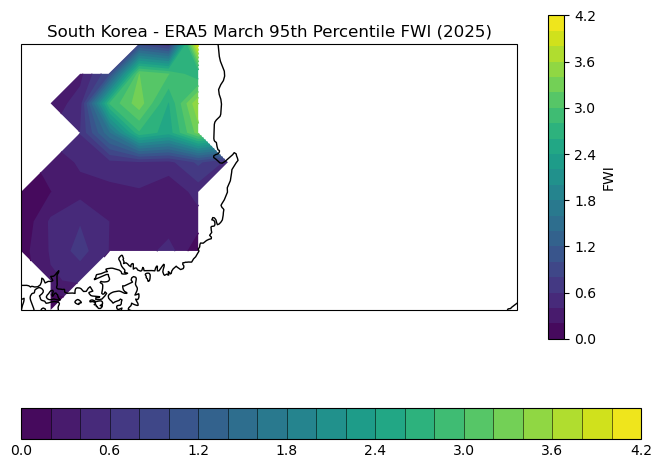

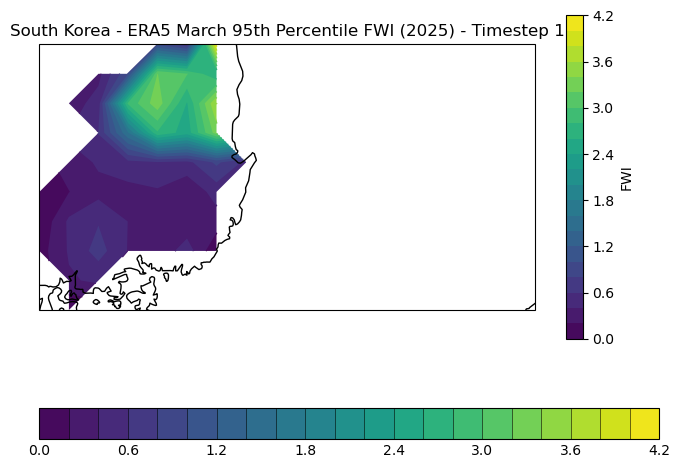

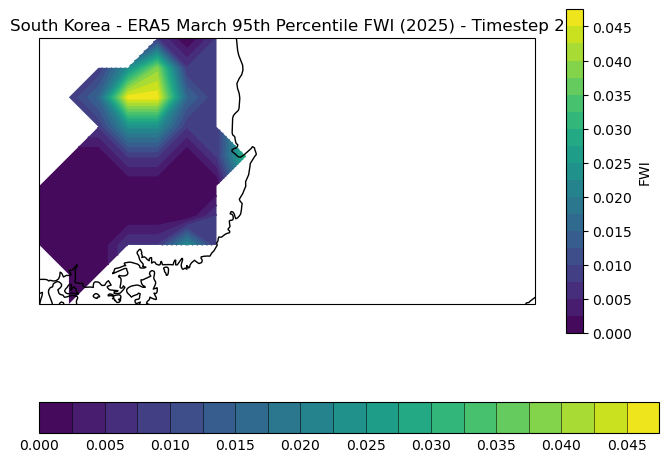

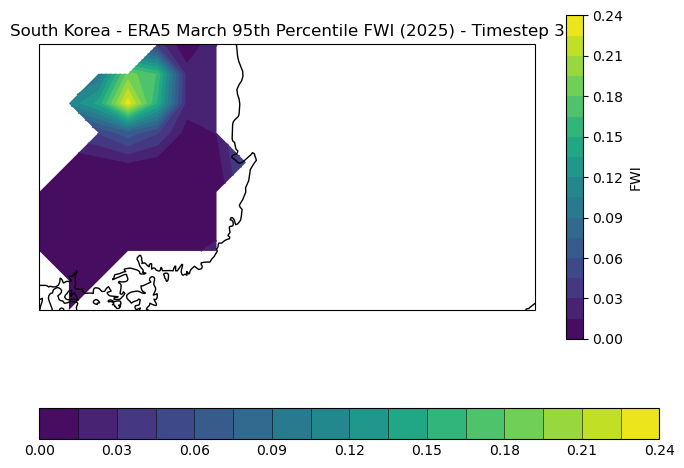

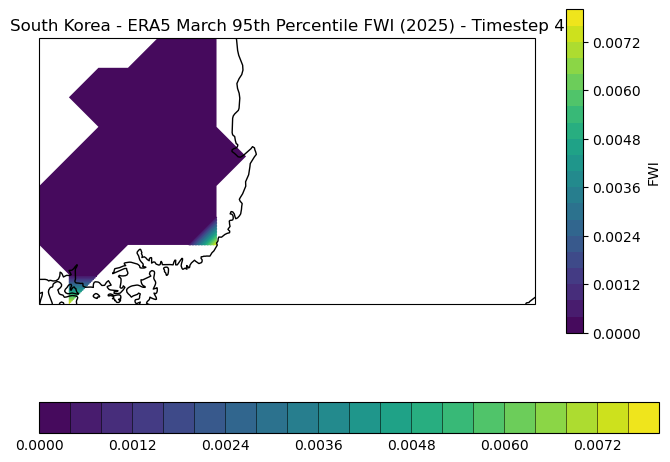

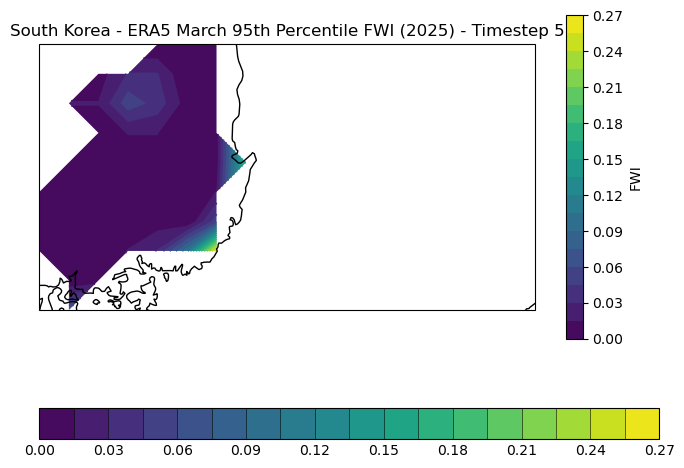

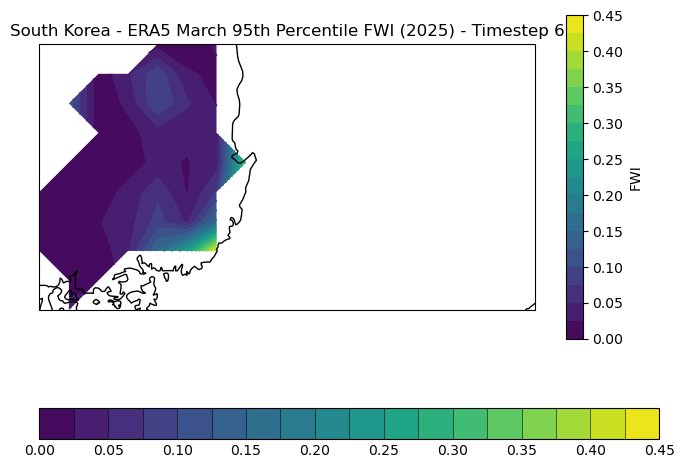

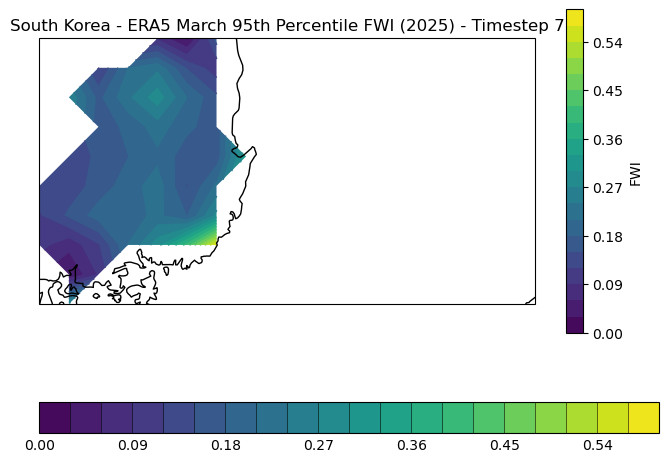

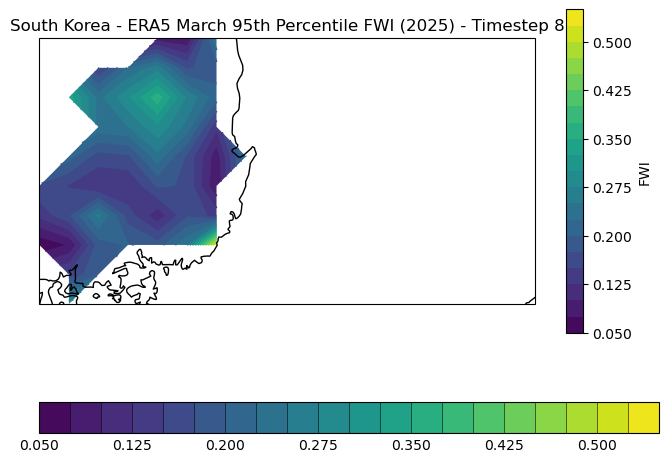

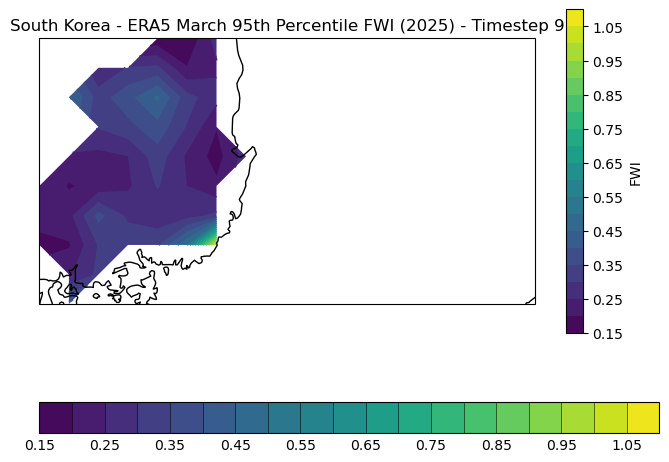

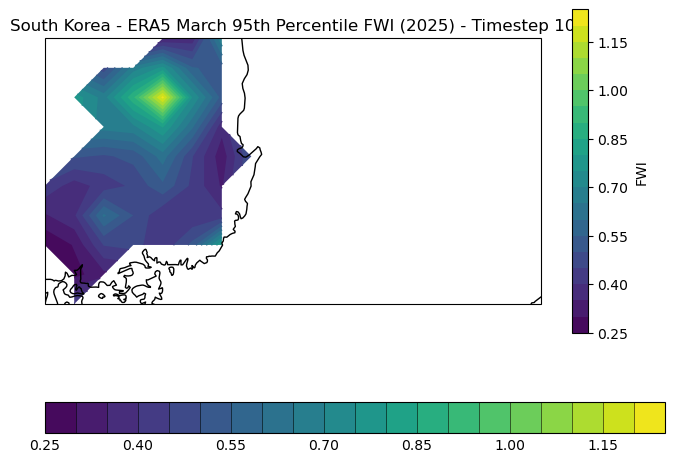

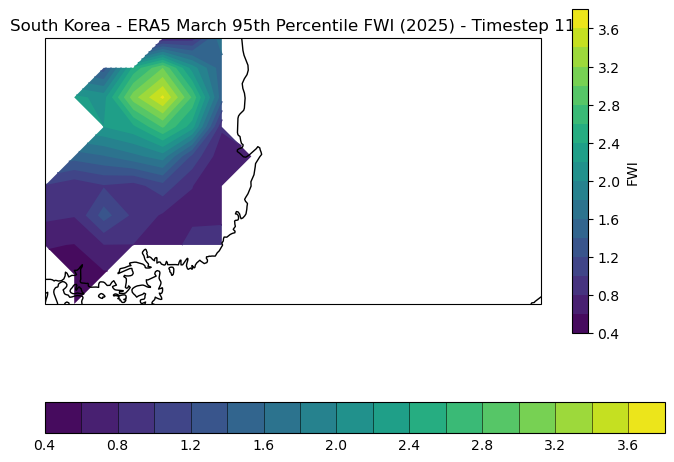

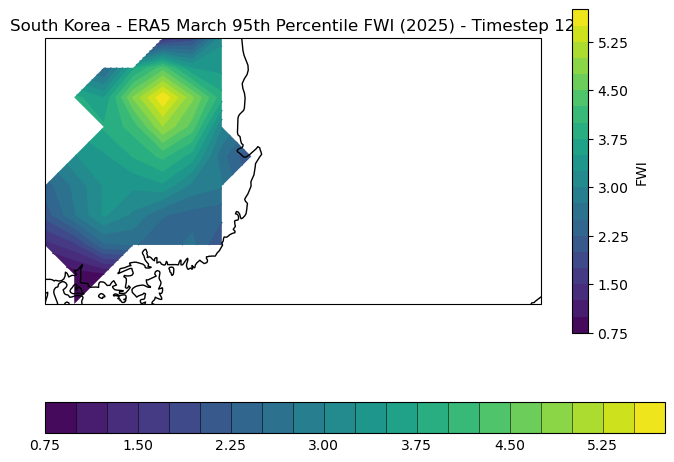

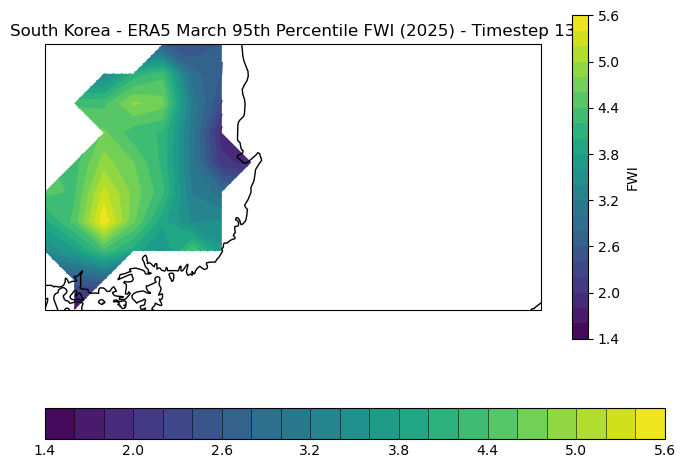

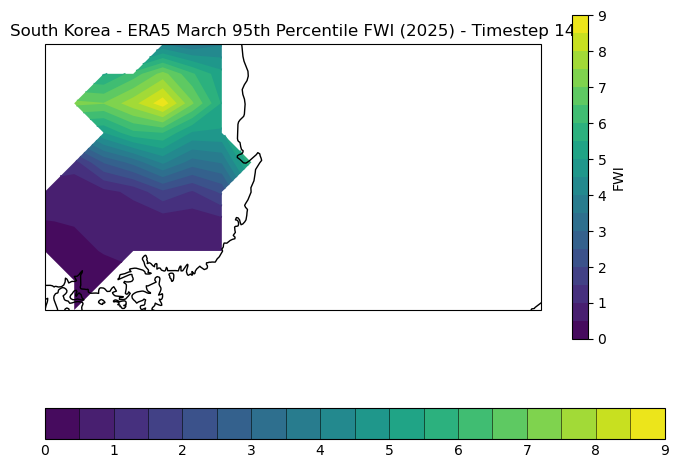

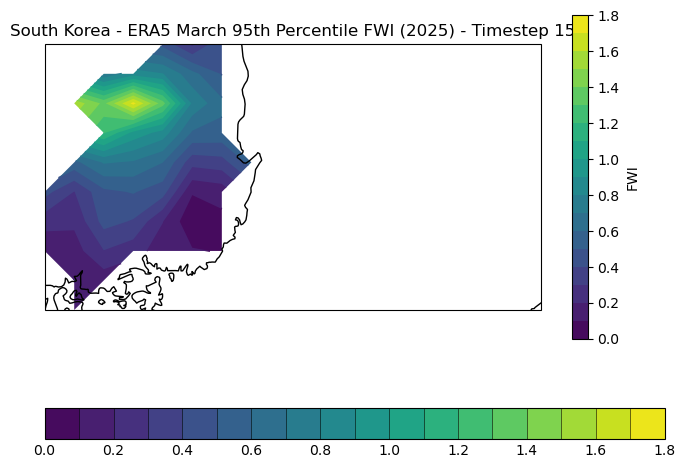

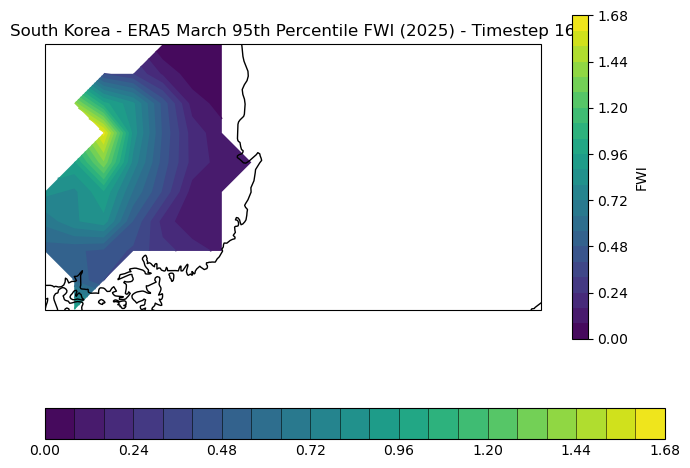

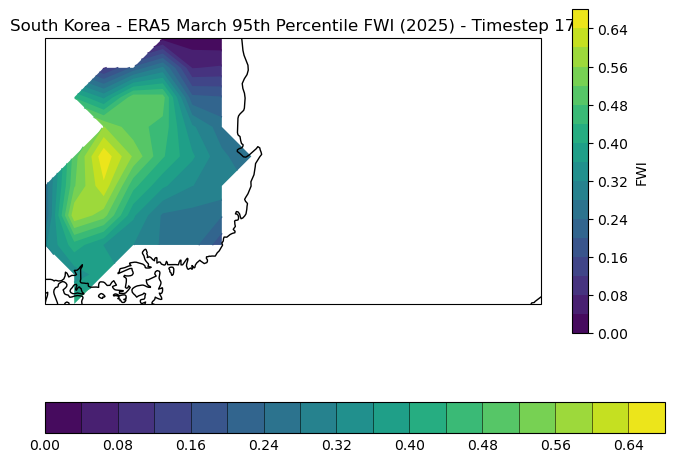

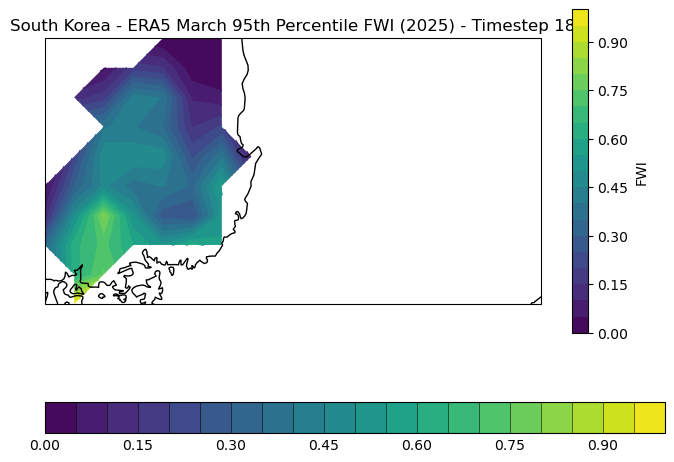

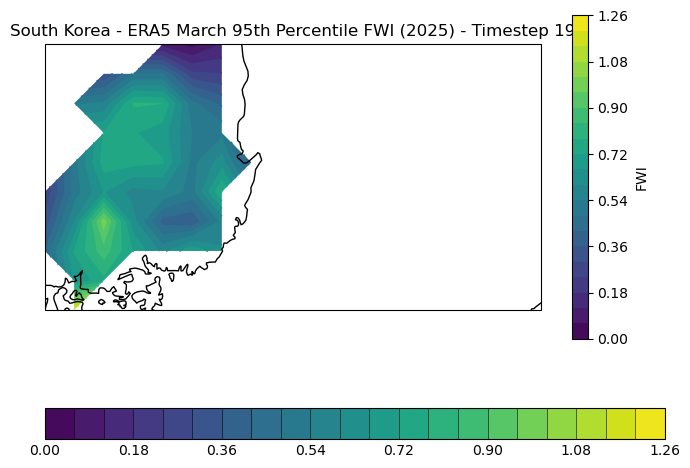

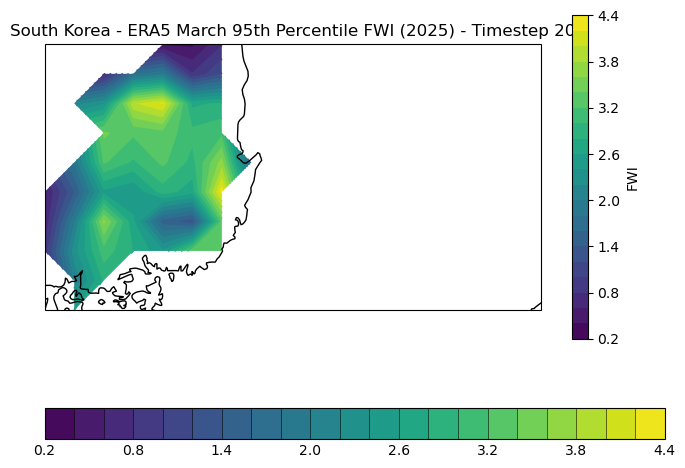

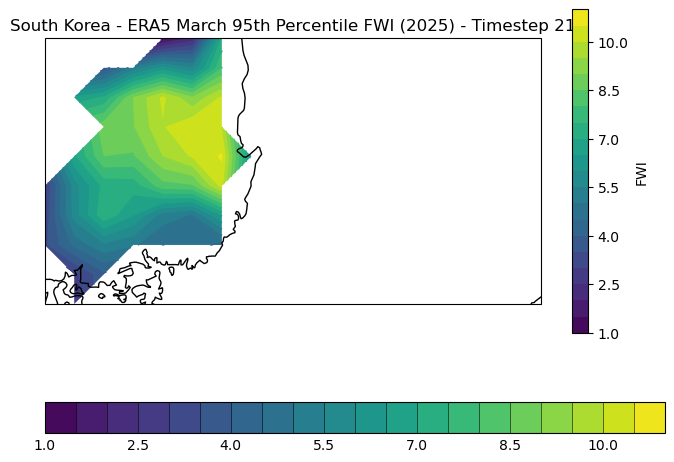

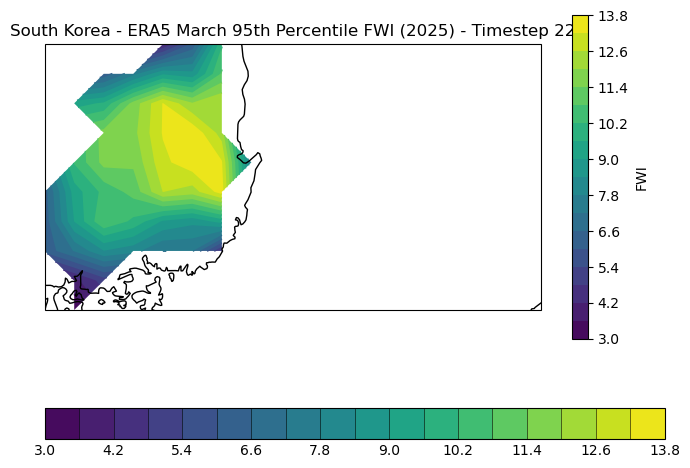

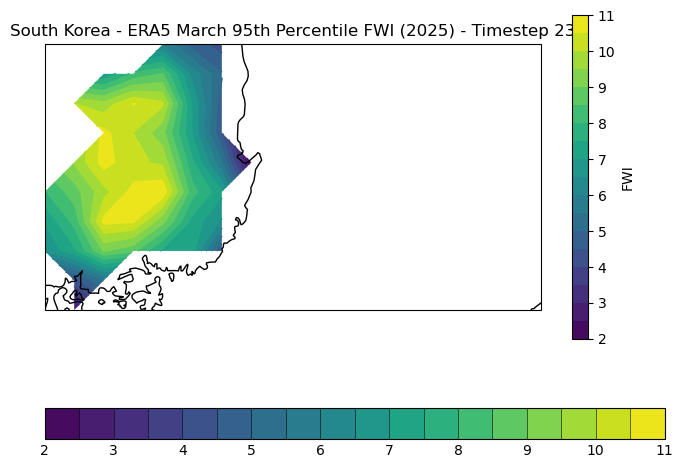

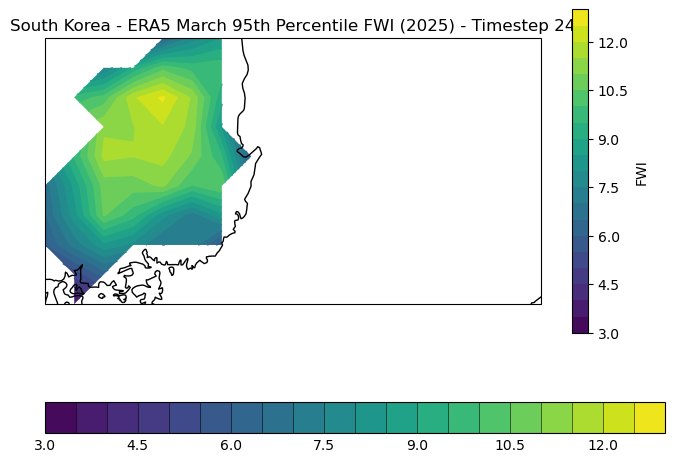

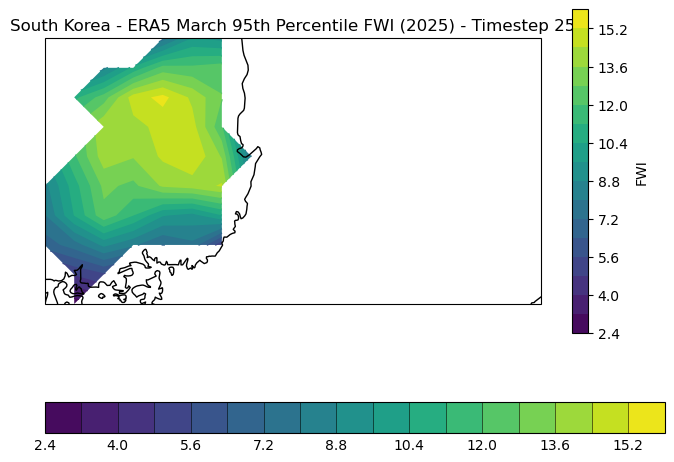

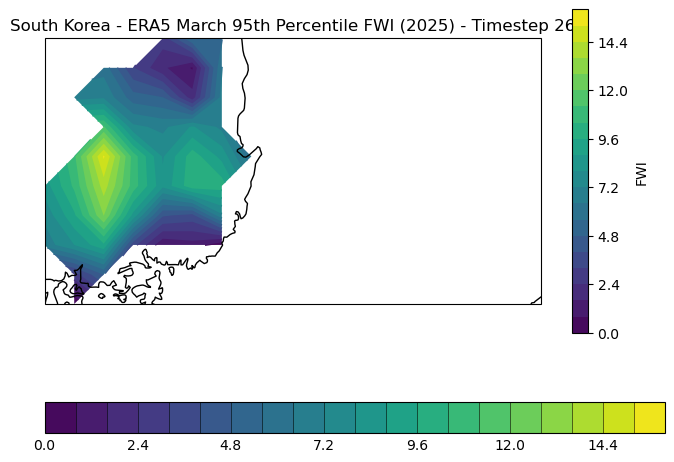

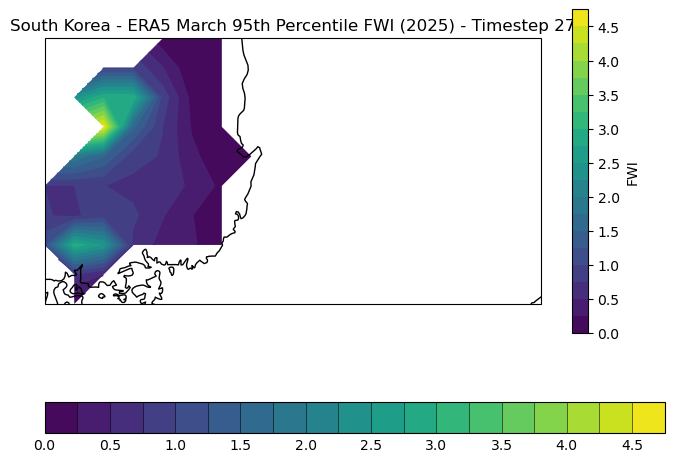

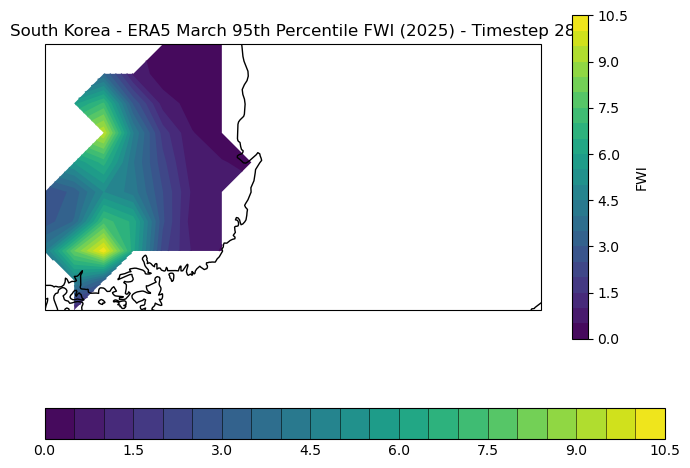

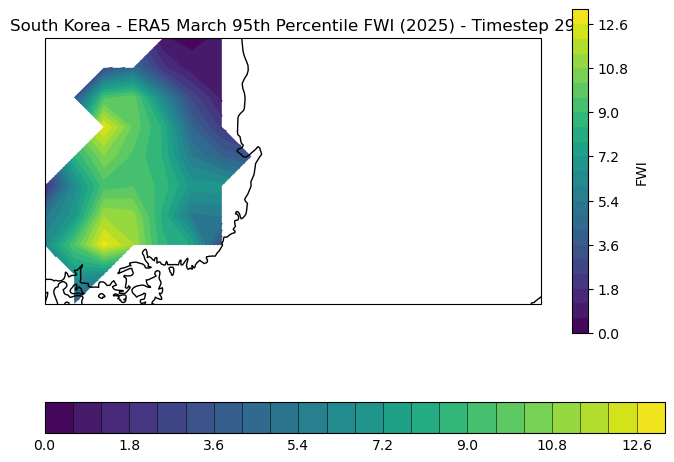

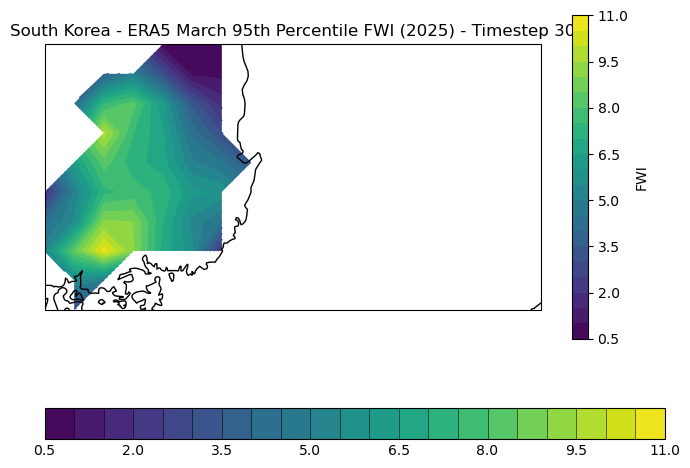

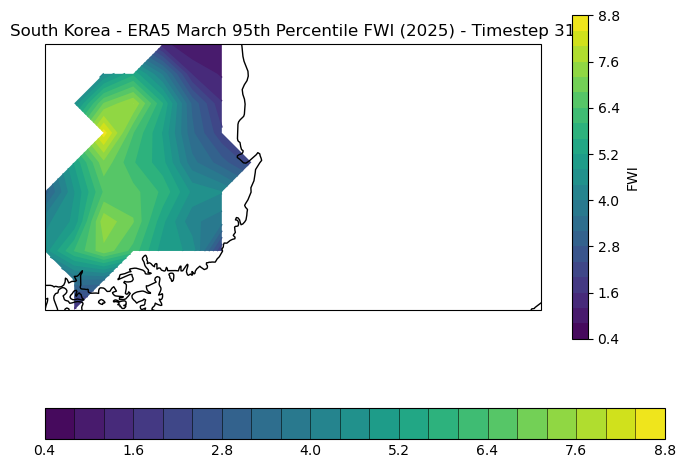

12.769921874999998
12.769921874999998


In [1]:
#Country = 'Scotland'
import iris
import warnings
import matplotlib.pyplot as plt 
import iris.quickplot as qplt
warnings.filterwarnings("ignore", category=UserWarning, module='iris')
warnings.filterwarnings("ignore", category=FutureWarning, module='iris')
from utils.constrain_cubes_standard import *
from utils.cubefuncs import GetERA5Threshold, CountryPercentile, TimePercentile

shp_file = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
# Month = 6
# month = 'June'
# percentile = 95
# shape_name = 'Scottish Highlands'
# ERA5_2025 = '/data/scratch/chantelle.burton/impactstoolbox/Data/era5/Fire-Weather/FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-08-01_global_day_initialise-from=copernicus-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc'

print('Running South Korea')
Month = 3
month = 'March'
percentile = 95
shape_name = 'South Korea'
ERA5_2025 = '/data/scratch/chantelle.burton/SoW2526/Y2526FWI/FWI_ERA5_std_reanalysis_2025-01-01-2025-05-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc'
print(ERA5_2025)
threshold_ERA5_2025 = GetERA5Threshold(ERA5_2025, shp_file, shape_name, Month, percentile)
print(f"ERA5 2025 {month} {percentile}th percentile threshold for {shape_name}: {threshold_ERA5_2025}") #5.208984374999998 for original (Scotland 95th percentile value for July 2025)

era5_cube = iris.load_cube(ERA5_2025, 'canadian_fire_weather_index')
print(era5_cube)
# 1. Apply month constraint FIRST (matching original)
if isinstance(Month, tuple):
    daterange = iris.Constraint(time=lambda cell: cell.point.month in Month)
else:
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)

era5_cube = era5_cube.extract(daterange)
#print(era5_cube)
# 2. Apply shapefile mask
era5_cube = contrain_to_sow_shapefile(era5_cube, shp_file, shape_name)
#print(era5_cube)
plt.figure(figsize=(8, 6))
qplt.contourf(era5_cube[0], 20)
plt.gca().coastlines()
plt.title(f"{shape_name} - ERA5 {month} {percentile}th Percentile FWI (2025)")
plt.colorbar(label='FWI')
# Plot every timestep in the cube
for i, t in enumerate(era5_cube.slices_over('time')):
    plt.figure(figsize=(8, 6))
    qplt.contourf(t, 20)
    plt.gca().coastlines()
    plt.title(f"{shape_name} - ERA5 {month} {percentile}th Percentile FWI (2025) - Timestep {i+1}")
    plt.colorbar(label='FWI')
    plt.show()
# 3. Spatial percentile
era5_cube = CountryPercentile(era5_cube, percentile)



# 4. Temporal percentile
era5_cube = TimePercentile(era5_cube, percentile)
print(era5_cube.data)
print(float(np.array(era5_cube.data)))

#choose max value on any given day - but check for wacky values.


In [ ]:
import numpy as np

# Calculate and print statistics for both distributions

data1_np = np.array(data1)
data2_np = np.array(data2)
data3_np = np.array(data3)

def print_stats(data, label):
    print(f"Stats for {label}:")
    print(f"  Count: {len(data)}")
    print(f"  Mean: {np.mean(data):.4f}")
    print(f"  Median: {np.median(data):.4f}")
    print(f"  Std: {np.std(data):.4f}")
    print(f"  Min: {np.min(data):.4f}")
    print(f"  Max: {np.max(data):.4f}")
    print(f"  5th percentile: {np.percentile(data, 5):.4f}")
    print(f"  95th percentile: {np.percentile(data, 95):.4f}\n")

print_stats(data1_np, "July Only")
print_stats(data2_np, "Dual Months")
print_stats(data3_np, "June Only")

In [ ]:
import matplotlib.pyplot as plt

# Plot all three distributions on one figure
plt.figure(figsize=(10,6))
plt.hist(data1, bins=20, alpha=0.5, label='JulyOnly')
plt.hist(data2, bins=20, alpha=0.5, label='DualMonths')
plt.hist(data3, bins=20, alpha=0.5, label='JuneOnly')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('All Distributions Comparison')
plt.legend()
plt.show()

# Plot each distribution individually in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

axs[0].hist(data1, bins=20, alpha=0.7, color='C0')
axs[0].set_title('Original')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Frequency')

axs[1].hist(data2, bins=20, alpha=0.7, color='C1')
axs[1].set_title('DualMonths')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Frequency')

axs[2].hist(data3, bins=20, alpha=0.7, color='C2')
axs[2].set_title('JuneOnly')
axs[2].set_xlabel('Value')
axs[2].set_ylabel('Frequency')

# Hide the unused subplot (bottom right)
axs[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# File patterns for each group
orig_pattern = "/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_[1-9,1][0-5]_95%.dat"
updated_pattern = "/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_Updated_[1-9,1][0-5]_95%.dat"
june_pattern = "/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_JuneOnly_[1-9,1][0-5]_95%.dat"

# Helper to load and concatenate all .dat files for a pattern
def load_group(pattern):
    files = sorted(glob.glob(pattern))
    data = []
    for f in files:
        try:
            arr = np.loadtxt(f)
            data.append(arr)
        except Exception as e:
            print(f"Error loading {f}: {e}")
    if data:
        return np.concatenate(data)
    else:
        return np.array([])

# Load all groups
data_orig = load_group("/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_[1-9,1][0-5]_95%.dat")
data_updated = load_group("/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_Updated_[1-9,1][0-5]_95%.dat")
data_june = load_group("/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_JuneOnly_[1-9,1][0-5]_95%.dat")

# Plot all on one figure
plt.figure(figsize=(10,6))
plt.hist(data_orig, bins=20, alpha=0.5, label='Original')
plt.hist(data_updated, bins=20, alpha=0.5, label='DualMonths')
plt.hist(data_june, bins=20, alpha=0.5, label='JuneOnly')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('HadGEM3 Scotland 95% Distributions (All Members)')
plt.legend()
plt.show()

# Plot each group individually in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()
axs[0].hist(data_orig, bins=20, alpha=0.7, color='C0')
axs[0].set_title('Original')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Frequency')
axs[1].hist(data_updated, bins=20, alpha=0.7, color='C1')
axs[1].set_title('DualMonths')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Frequency')
axs[2].hist(data_june, bins=20, alpha=0.7, color='C2')
axs[2].set_title('JuneOnly')
axs[2].set_xlabel('Value')
axs[2].set_ylabel('Frequency')
axs[3].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import xarray as xr
fwi_grib = xr.open_dataset('/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI-2018-2026-0.25.grib',engine = 'cfgrib')
print(fwi_grib)

In [19]:
# Subset ERA5 FWI grib to Scotland, June/July 2025, and compute 95th percentiles
import xarray as xr
import numpy as np
import pandas as pd

# Open the dataset (already loaded as fwi_grib)
# fwi_grib = xr.open_dataset('/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI-2018-2026-0.25.grib', engine='cfgrib')

# 1. Subset to June/July 2025
time_sel = fwi_grib.sel(time=slice('2025-06-01', '2025-07-31'))

# 2. Subset to Scotland (tighter bounding box: lon -6 to -0.5, lat 54.5 to 60.5)
scotland = time_sel.sel(latitude=slice(60.5, 56.5), longitude=slice(-6 % 360, -0.5 % 360))

# 3. Calculate spatial 95th percentile for each timestep (over Scotland)
spatial_95 = scotland['fwinx'].quantile(0.95, dim=["latitude", "longitude"])

# 4. Calculate temporal 95th percentile (over all selected timesteps)
temporal_95 = spatial_95.quantile(0.95, dim="time")

print("Spatial 95th percentile for each timestep (June/July 2025, Scotland):")
print(spatial_95.values)
print("\nTemporal 95th percentile of those values:")
print(float(temporal_95.values))

Spatial 95th percentile for each timestep (June/July 2025, Scotland):
[ 1.17226562  3.64277344  5.34941406 10.30019531  7.79433594  3.35976562
  2.4890625   5.16035156  2.83339844  0.95859375  2.34238281  8.21015625
  8.58046875  2.54199219  1.30703125  3.70117188  2.89785156  5.74199219
  5.35703125  9.28769531 10.17636719  3.69824219  6.13828125  4.65820312
  5.27265625  3.23710938  3.88945313  6.89609375  8.42988281 11.49628906
  0.45488281  0.84785156  0.96914062  0.97558594  1.49042969  0.69316406
  5.2734375   3.44160156  6.54453125  8.64707031  7.86210938  9.58964844
 12.10429687 19.33847656  1.85976562  3.540625   10.07246094  9.1265625
  7.48144531  3.4734375   2.03164062  0.96894531  0.67324219  1.61152344
  3.80410156  6.46875     2.43398437  3.20351562  3.51523437  4.93789062
  5.459375  ]

Temporal 95th percentile of those values:
10.300195312499998


In [ ]:
# Plot a map of the first timestep of the Scotland FWI slice with local Scotland shapefile outline
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
fwi_grib = xr.open_dataset('/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI-2018-2026-0.25.grib', engine='cfgrib')

# Use the first timestep for plotting
fwi_slice = scotland['fwinx'].isel(time=1)

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the FWI data
fwi_slice.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', cbar_kwargs={'label': 'FWI'})

# Add coastlines and borders
ax.coastlines(resolution='10m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Add local Scotland shapefile outline
shapefile_path = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
gdf = gpd.read_file(shapefile_path)
gdf.boundary.plot(ax=ax, edgecolor='blue', linewidth=2, label='Scotland outline')

#ax.set_extent([-8, -0.5, 54.5, 61])
plt.title('FWI (first timestep, June/July 2025) with Scotland outline (local shapefile)')
plt.legend()
plt.show()

NameError: name 'scotland' is not defined

In [2]:
# Xarray-based GetERA5Threshold equivalent for .grib data using shapefile mask
import xarray as xr
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

# Function to compute threshold
def get_xr_threshold(ds, shp_file, shape_name, months, percentile):
    # 1. Subset to 2025 and selected months
    ds_sel = ds.sel(time=ds['time'].dt.year == 2025)
    ds_sel = ds_sel.sel(time=ds_sel['time'].dt.month.isin(months))
    
    # 2. Load shapefile and select region
    gdf = gpd.read_file(shp_file)
    region = gdf[gdf['name'] == shape_name]
    if region.empty:
        raise ValueError(f"Shape '{shape_name}' not found in shapefile.")
    
    # 3. Create mask for grid points inside the region
    lats = ds_sel.latitude.values
    lons = ds_sel.longitude.values
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(lon_grid.flatten(), lat_grid.flatten())])
    mask = points.within(region.unary_union).values.reshape(lat_grid.shape)
    
    # 4. Apply mask and compute spatial percentile for each timestep
    masked = ds_sel['fwinx'].where(mask)
    spatial = masked.reduce(np.nanpercentile, axis=(1,2), q=percentile)
    
    # 5. Compute temporal percentile
    threshold = np.nanpercentile(spatial, percentile)
    return threshold

# Example usage
shp_file = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
shape_name = 'South Korea'  # Change as needed
months = [6, 7]
percentile = 95

threshold = get_xr_threshold(fwi_grib, shp_file, shape_name, months, percentile)
print(f"ERA5 FWI threshold for {shape_name}, June/July 2025, {percentile}th percentile: {threshold}")

NameError: name 'fwi_grib' is not defined

In [23]:
# Debug version: Fix longitude convention and print mask coverage
import xarray as xr
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

def get_xr_threshold_debug(ds, shp_file, shape_name, months, percentile):
    ds_sel = ds.sel(time=ds['time'].dt.year == 2025)
    ds_sel = ds_sel.sel(time=ds_sel['time'].dt.month.isin(months))
    gdf = gpd.read_file(shp_file)
    print('Available region names:', gdf['name'].unique())
    region = gdf[gdf['name'] == shape_name]
    if region.empty:
        raise ValueError(f"Shape '{shape_name}' not found in shapefile.")
    lats = ds_sel.latitude.values
    lons = ds_sel.longitude.values
    # Convert lons from 0–360 to -180–180 if needed
    lons = np.where(lons > 180, lons - 360, lons)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(lon_grid.flatten(), lat_grid.flatten())])
    mask = points.within(region.unary_union).values.reshape(lat_grid.shape)
    print('Mask coverage (number of grid points inside region):', np.sum(mask))
    masked = ds_sel['fwinx'].where(mask)
    spatial = masked.reduce(np.nanpercentile, axis=(1,2), q=percentile)
    print('Spatial percentile array:', spatial.values)
    threshold = np.nanpercentile(spatial, percentile)
    return threshold

# Example usage
shp_file = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
shape_name = 'Scottish Highlands'  # Change as needed
months = [6, 7]
percentile = 95

threshold = get_xr_threshold_debug(fwi_grib, shp_file, shape_name, months, percentile)
print(f"ERA5 FWI threshold for {shape_name}, June/July 2025, {percentile}th percentile: {threshold}")

Available region names: <StringArray>
[                      'Northwest Iberia',
     'Midwestern Canadian Shield forests',
 'Chilean Temperate Forests and Matorral',
                     'Scottish Highlands',
                  'Southeast South Korea']
Length: 5, dtype: str


/var/tmp/ipykernel_920385/1427493630.py:21: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mask = points.within(region.unary_union).values.reshape(lat_grid.shape)


Mask coverage (number of grid points inside region): 131
Spatial percentile array: [ 1.2871094   4.779297    3.8046875   8.765625    8.1171875   3.9941406
  2.1679688   2.3203125   1.7578125   0.6582031   2.3535156   8.119141
  9.7890625   2.2402344   1.4804688   4.6523438   3.9160156   6.8222656
  6.0195312   9.662109   11.417969    6.140625    6.453125    5.373047
  5.8378906   3.5039062   4.1875      7.484375    9.337891   12.626953
  0.8105469   0.92578125  0.68359375  0.6855469   1.8925781   0.8828125
  6.0976562   3.8535156   7.0097656   9.529297    8.238281   10.517578
 12.798828   20.683594    2.421875    3.734375   10.5390625  12.0390625
  8.666016    0.19335938  0.22070312  0.17773438  0.65234375  1.1328125
  3.9414062   6.595703    2.1445312   3.2792969   2.8964844   5.4023438
  7.234375  ]
ERA5 FWI threshold for Scottish Highlands, June/July 2025, 95th percentile: 12.0390625


In [3]:
import geopandas as gpd
shp_file = '/data/scratch/bob.potts/sowf/shapefiles/ne_50m_admin_0_map_units.shp'
gdf = gpd.read_file(shp_file)
print(gdf.columns)
print(gdf['NAME'].unique())

print(gdf[gdf['NAME'].str.contains('Scotland')])

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)
<StringArray>
[       'Zimbabwe',          'Zambia',           'Yemen',         'Vietnam',
       'Venezuela',         'Vatican',         'Vanuatu',      'Uzbekistan',
         'Uruguay',      'Micronesia',
 ...
         'Barbuda',          'Angola',         'Andorra',         'Algeria',
         'Albania',     'Afghanistan', 'Siachen Glacier',      'Antarctica',
    'Sint Maarten',          'Tuvalu']
Length: 265, dtype: str
          featurecla  scalerank  LABELRANK      SOVEREIGNT SOV_A3  ADM0_DIF  \
32  Admin-0 map unit          1          5  United Kingdom    GB1         1   

    LEVEL      TYPE TLC           ADMIN  ...       FCLASS_TR  FCLASS_ID  \
32      3  Geo unit   1  Uni

In [ ]:
# Select country, plot, and find threshold from GRIB file

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# --- User options ---
country = "South Korea"  # Options: "Scotland", "Iberia", "Canada", etc.
grib_path = "/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI-2018-2026-0.25.grib"
percentile = 95
time_range = ("2025-03-01", "2025-03-31")

# --- Country bounding boxes (add more as needed) ---
country_bounds = {
    "Scotland": dict(lat=(60.5, 56.5), lon=(-6, -0.5)),
    "Iberia": dict(lat=(44, 36), lon=(-10, 4)),
    "Canada": dict(lat=(60, 45), lon=(-140, -50)),
    "South Korea": dict(lat=(38, 33), lon=(125, 130)),
}

# --- Open GRIB file ---
fwi_grib = xr.open_dataset(grib_path, engine="cfgrib")

# --- Subset by time ---
time_sel = fwi_grib.sel(time=slice(*time_range))

# --- Subset by country bounding box ---
bounds = country_bounds[country]
region = time_sel.sel(
    latitude=slice(bounds["lat"][0], bounds["lat"][1]),
    longitude=slice(bounds["lon"][0] % 360, bounds["lon"][1] % 360)
)

# --- Calculate spatial percentile for each timestep ---
spatial_p = region["fwinx"].quantile(percentile / 100, dim=["latitude", "longitude"])

# --- Calculate temporal percentile over all selected timesteps ---
temporal_p = float(spatial_p.quantile(percentile / 100, dim="time").values)

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.plot(region["time"], spatial_p, label=f"Spatial {percentile}th percentile")
plt.axhline(temporal_p, color="red", linestyle="--", label=f"Temporal {percentile}th percentile")
plt.title(f"{country} FWI {percentile}th Percentile ({time_range[0]} to {time_range[1]})")
plt.xlabel("Time")
plt.ylabel("FWI")
plt.legend()
plt.show()

print(f"Temporal {percentile}th percentile value: {temporal_p}")